In [1]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier, DMatrix, train
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

In [2]:
# 2. Load dataset and preprocessing
file_path = "Supply Chain Dashboard and Analysis.xlsx"
xls = pd.ExcelFile(file_path)
df_raw = xls.parse("Raw Data")
df_order = xls.parse("Order Tracker")

In [3]:
# 3. Merging datasets and preprocessing
merged_df = df_raw.merge(df_order[['SKU', 'Supplier ReOrder']], on='SKU', how='left')
merged_df.rename(columns={'Supplier ReOrder': 'Selected Supplier'}, inplace=True)
merged_df['Selected Supplier'] = merged_df['Selected Supplier'].map({'Yes': 1, 'No': 0})

In [4]:
# Drop irrelevant columns
columns_to_drop = [col for col in ['SKU', 'Product type', 'Supplier name','Customer demographics', 'Routes', 'Inspection results','Suppier name'] if col in merged_df.columns]
data = merged_df.drop(columns=columns_to_drop, errors='ignore')

In [5]:
data.head()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping carriers,Shipping costs,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Transportation modes,Costs,Selected Supplier
0,69.808006,55,802,8661.996792,58,7,96,4,Carrier B,2.956572,Mumbai,29,215,29,46.279879,0.226410,Road,187.752075,1
1,14.843523,95,736,7460.900065,53,30,37,2,Carrier A,9.716575,Mumbai,23,517,30,33.616769,4.854068,Road,503.065579,1
2,11.319683,34,8,9577.749626,1,10,88,2,Carrier B,8.054479,Mumbai,12,971,27,30.688019,4.580593,Air,141.920282,0
3,61.163343,68,83,7766.836426,23,13,59,6,Carrier C,1.729569,Kolkata,24,937,18,35.624741,4.746649,Rail,254.776159,0
4,4.805496,26,871,2686.505152,5,3,56,8,Carrier A,3.890548,Delhi,5,414,3,92.065161,3.145580,Air,923.440632,1


In [6]:
data['Transportation modes'].unique()

array(['Road', 'Air', 'Rail', 'Sea'], dtype=object)

In [7]:
# Handle missing data
for col in data.columns:
    if data[col].dtype == 'object':
        data[col].fillna(data[col].mode()[0], inplace=True)
    else:
        data[col].fillna(data[col].median(), inplace=True)

C:\Users\as219\AppData\Local\Temp\ipykernel_12412\2157552165.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)
C:\Users\as219\AppData\Local\Temp\ipykernel_12412\2157552165.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [ ]:
label_encoders = {}
categorical_columns = data.select_dtypes(include=['object']).columns.tolist()
if categorical_columns:
    for col in categorical_columns:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str)) 
        label_encoders[col] = le

In [ ]:

X = data.drop(columns=['Selected Supplier'])
y = data['Selected Supplier']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
dtrain = DMatrix(X_train, label=y_train)
dtest = DMatrix(X_test, label=y_test)

In [ ]:
params = {
    'max_depth': 5,
    'min_child_weight': 2,
    'gamma': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'lambda': 1,
    'alpha': 0.5,
    'eval_metric': 'logloss',
    'objective': 'binary:logistic',
    'random_state': 42
}

In [ ]:
watchlist = [(dtrain, 'train'), (dtest, 'eval')]  
num_round = 1000  
early_stopping_rounds = 10  

In [14]:
# Train the model
bst = train(params, dtrain, num_round, watchlist, early_stopping_rounds=early_stopping_rounds, verbose_eval=True)

[0]	train-logloss:0.58100	eval-logloss:0.42531
[1]	train-logloss:0.48852	eval-logloss:0.40883
[2]	train-logloss:0.43297	eval-logloss:0.38323
[3]	train-logloss:0.37063	eval-logloss:0.33871
[4]	train-logloss:0.33018	eval-logloss:0.34933
[5]	train-logloss:0.30207	eval-logloss:0.35810
[6]	train-logloss:0.27543	eval-logloss:0.31331
[7]	train-logloss:0.25093	eval-logloss:0.27335
[8]	train-logloss:0.23242	eval-logloss:0.25090
[9]	train-logloss:0.21367	eval-logloss:0.23716
[10]	train-logloss:0.20357	eval-logloss:0.22739
[11]	train-logloss:0.19693	eval-logloss:0.22029
[12]	train-logloss:0.18669	eval-logloss:0.22811
[13]	train-logloss:0.17281	eval-logloss:0.20951
[14]	train-logloss:0.16513	eval-logloss:0.20127
[15]	train-logloss:0.16041	eval-logloss:0.19768
[16]	train-logloss:0.15747	eval-logloss:0.19912
[17]	train-logloss:0.15432	eval-logloss:0.19378
[18]	train-logloss:0.14999	eval-logloss:0.20625
[19]	train-logloss:0.14695	eval-logloss:0.19366
[20]	train-logloss:0.14325	eval-logloss:0.19748
[2

c:\Users\as219\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:726: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


In [ ]:
# 9. Predict and evaluate the model
y_pred = bst.predict(dtest, iteration_range=(0, bst.best_iteration)) 
y_pred_binary = (y_pred > 0.5).astype(int)  

In [16]:
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_binary))

Accuracy: 1.00

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00        18

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [17]:
# 10. Perform k-fold cross-validation for more reliable performance estimate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(XGBClassifier(**params), X, y, cv=cv, scoring='accuracy')
print(f"Cross-validated accuracy scores: {cv_scores}")
print(f"Mean Cross-validated accuracy: {cv_scores.mean():.2f}")

Cross-validated accuracy scores: [1.  1.  1.  0.8 0.8]
Mean Cross-validated accuracy: 0.92


In [ ]:
params1 = {
    'alpha': 1,  
    'colsample_bytree': 0.7,
    'gamma': 0.1,
    'lambda': 1.5,
    'max_depth': 3,
    'min_child_weight': 1,
    'subsample': 0.8
}

In [19]:

model = XGBClassifier(**params1)

model.fit(X_train,y_train)

XGBClassifier(alpha=1, base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None, lambda=1.5,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None, ...)

In [ ]:
y_pred_best = model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Accuracy: {accuracy_best:.2f}")
print("\nClassification Report (Best Model):\n", classification_report(y_test, y_pred_best))

Accuracy: 0.95

Classification Report (Best Model):
               precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.94      0.97        18

    accuracy                           0.95        20
   macro avg       0.83      0.97      0.89        20
weighted avg       0.97      0.95      0.95        20



In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='rbf', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XG Boost" : XGBClassifier(**params1)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results[name] = {
        "Accuracy": round(acc * 100, 2),
        "Precision": round(report['1']['precision'] * 100, 2),
        "Recall": round(report['1']['recall'] * 100, 2),
        "F1-score": round(report['1']['f1-score'] * 100, 2)
    }
    
    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.2f}")
    print(classification_report(y_test, y_pred))

print("\nFinal Results (all models):")
for k, v in results.items():
    print(f"{k}: {v}")

c:\Users\as219\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\as219\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\as219\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.p


=== Logistic Regression ===
Accuracy: 0.90
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       1.00      0.89      0.94        18

    accuracy                           0.90        20
   macro avg       0.75      0.94      0.80        20
weighted avg       0.95      0.90      0.91        20


=== SVM ===
Accuracy: 0.90
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.90      1.00      0.95        18

    accuracy                           0.90        20
   macro avg       0.45      0.50      0.47        20
weighted avg       0.81      0.90      0.85        20


=== Random Forest ===
Accuracy: 0.90
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.94      0.94      0.94        18

    accuracy                           0.90        20
   macro avg      

AUC-ROC Score (XGBClassifier): 0.9722


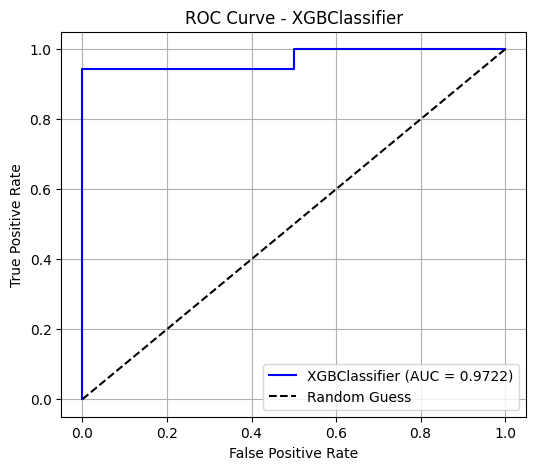

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Predict probabilities using the fitted XGBClassifier model
y_pred_proba2 = model.predict_proba(X_test)[:, 1]  

# Calculate AUC score
auc_score2 = roc_auc_score(y_test, y_pred_proba2)
print(f"AUC-ROC Score (XGBClassifier): {auc_score2:.4f}")

# Compute ROC curve
fpr2, tpr2, thresholds2 = roc_curve(y_test, y_pred_proba2)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr2, tpr2, label=f'XGBClassifier (AUC = {auc_score2:.4f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBClassifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [23]:
# 13. Save the trained model to disk (optional)
import pickle
with open('model1.pkl', 'wb') as file:
    pickle.dump(model, file)

In [35]:
X_train

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping carriers,Shipping costs,Supplier name,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Transportation modes,Costs
55,79.855058,16,701,2925.675170,97,11,11,5,0,5.014365,1,2,27,918,5,30.323545,4.548920,3,323.012928
88,75.270407,58,737,9444.742033,60,18,85,7,0,3.801253,1,4,21,953,11,68.184919,0.722204,3,103.916248
26,97.446947,9,353,3716.493326,59,16,48,4,1,6.507549,1,0,26,171,4,15.972230,2.119320,1,617.866916
42,46.529168,98,155,1839.609426,22,27,57,4,2,7.526248,4,0,26,179,7,96.422821,4.939255,2,635.657121
69,54.865529,62,511,1752.381087,95,1,27,3,1,9.705287,3,3,9,862,7,77.627766,1.362388,0,207.663206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,17.028028,16,380,8864.084350,41,27,72,8,2,4.381368,3,4,29,929,24,87.213058,2.853091,1,430.169097
71,6.381533,14,637,8180.337085,76,2,26,6,0,9.228190,1,0,2,258,10,30.661677,2.078751,2,405.167068
14,99.171329,26,562,8653.570926,54,29,78,5,1,2.039770,0,3,25,558,14,5.791437,0.100683,0,929.235290
92,47.714233,44,276,2100.129755,90,25,10,8,1,4.469500,1,4,4,671,29,62.612690,0.333432,1,230.092783


In [39]:
# 14. Predict using a new example (optional)
new_supplier = np.array([[
    54.8655285170697, 62, 511, 1752.38108748412, 95, 1, 27, 3, 1, 9.71,
    3, 3, 9, 862, 7, 77.6278, 1.3624, 0, 207.663206208575
]])
print(model.predict(new_supplier))

[0]


In [38]:
new_supplier1 = np.array([[
    46.529168, 98, 155, 1839.609426, 22, 27, 57, 4, 2, 7.526248,
    4, 0, 26, 179, 7, 96.422821, 	4.939255, 2, 635.657121
]])
print(model.predict(new_supplier))

[1]


In [14]:
X_train.columns

Index(['Price', 'Availability', 'Number of products sold', 'Revenue generated',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Defect rates', 'Transportation modes', 'Costs'],
      dtype='object')

In [24]:
# Save label encoders
with open('label_encoders1.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)